In [1]:
import numpy as np
import pandas as pd

In [2]:
tiempo_celular = np.array([
    4.5, 2.8, 7.1, 5.0, 6.3, 3.2, 5.8, 4.1, 6.5, 3.9,
    7.8, 4.9, 5.3, 2.5, 6.0, 4.8, 3.0, 8.5, 6.7, 5.5,
    4.6, 2.9, 7.3, 5.1, 6.4, 3.3, 5.9, 4.2, 6.6, 4.0,
    7.9, 5.0, 5.4, 2.6, 6.1, 4.7, 3.1, 8.6, 6.8, 5.6,
    5.0, 2.7, 7.5, 5.2, 6.5, 3.4, 6.0, 4.3, 6.7, 4.1
])

df = pd.DataFrame({"tiempo_celular": tiempo_celular})

df.head()

,tiempo_celular
0,4.5
1,2.8
2,7.1
3,5.0
4,6.3


In [3]:
# numpy
n = np.size(tiempo_celular)
n

50

In [4]:
# pandas
df["tiempo_celular"].count()

np.int64(50)

In [5]:
# numpy
# cuanto usa en promedio el celular una persona
media = np.mean(tiempo_celular)
print(media)

5.234


In [6]:
# pandas
print(df["tiempo_celular"].mean())

5.234


In [7]:
# mediana
mediana = np.median(tiempo_celular)
mediana

np.float64(5.15)

In [8]:
# pandas
df["tiempo_celular"].median()

np.float64(5.15)

In [9]:
# moda
df["tiempo_celular"].mode()

0    5.0
Name: tiempo_celular, dtype: float64

In [10]:
df["tiempo_celular"].value_counts().sort_index()

tiempo_celular
2.5    1
2.6    1
2.7    1
2.8    1
2.9    1
3.0    1
3.1    1
3.2    1
3.3    1
3.4    1
3.9    1
4.0    1
4.1    2
4.2    1
4.3    1
4.5    1
4.6    1
4.7    1
4.8    1
4.9    1
5.0    3
5.1    1
5.2    1
5.3    1
5.4    1
5.5    1
5.6    1
5.8    1
5.9    1
6.0    2
6.1    1
6.3    1
6.4    1
6.5    2
6.6    1
6.7    2
6.8    1
7.1    1
7.3    1
7.5    1
7.8    1
7.9    1
8.5    1
8.6    1
Name: count, dtype: int64

In [11]:
# minimo maximo
minimo = np.min(tiempo_celular)
maximo = np.max(tiempo_celular)

minimo, maximo

(np.float64(2.5), np.float64(8.6))

In [12]:
# pandas
print(df["tiempo_celular"].min())
print(df["tiempo_celular"].max())

2.5
8.6


In [13]:
# Rango
rango = maximo - minimo
rango

np.float64(6.1)

In [14]:
# varianza
varianza_poblacional = np.var(tiempo_celular)
varianza_muestral = np.var(tiempo_celular, ddof=1)

print("varianza_poblacional = ", varianza_poblacional, "\nvarianza_muestral =", varianza_muestral)

varianza_poblacional =  2.566644 
varianza_muestral = 2.6190244897959185


In [15]:
# pandas
print(df["tiempo_celular"].var())

2.6190244897959185


In [16]:
# desviacion estandar
desviacion_poblacional = np.std(tiempo_celular)
desviacion_muestral = np.std(tiempo_celular, ddof=1)

print(desviacion_poblacional, desviacion_muestral)

1.602074904615886 1.6183400414609777


In [17]:
print(df["tiempo_celular"].std())

1.6183400414609777


In [18]:
# cuartiles
q1 = np.percentile(tiempo_celular, 25)
q2 = np.percentile(tiempo_celular, 50)
q3 = np.percentile(tiempo_celular, 75)

print(q1, q2, q3)

4.1 5.15 6.475


In [19]:
# pandas
df["tiempo_celular"].quantile([0.25, 0.50, 0.75])

0.25    4.100
0.50    5.150
0.75    6.475
Name: tiempo_celular, dtype: float64

## Rango intercuartílico, IQR ##

Fórmula:

$$IQR=Q3−Q1$$

In [20]:
iqr = q3 - q1
print(iqr)

2.375


## Valores atipicos
Un valor atípico es un dato que se aleja mucho del resto.

Una regla común es:
$$
Limite inferior=Q1−1.5×IQR$$
$$Limite superior=Q3+1.5×IQR$$

In [21]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
print(limite_inferior, limite_superior)

0.5374999999999996 10.0375


In [23]:
atipicos = df[
    (df["tiempo_celular"] < limite_inferior) |
    (df["tiempo_celular"] > limite_superior)
]

atipicos

,tiempo_celular


In [24]:
df["tiempo_celular"].describe()

count    50.00000
mean      5.23400
std       1.61834
min       2.50000
25%       4.10000
50%       5.15000
75%       6.47500
max       8.60000
Name: tiempo_celular, dtype: float64

In [25]:
resumen = pd.DataFrame({
    "Estadístico": [
        "Cantidad",
        "Media",
        "Mediana",
        "Moda",
        "Mínimo",
        "Máximo",
        "Rango",
        "Varianza muestral",
        "Desviación estándar muestral",
        "Q1",
        "Q3",
        "IQR"
    ],
    "Valor": [
        df["tiempo_celular"].count(),
        df["tiempo_celular"].mean(),
        df["tiempo_celular"].median(),
        df["tiempo_celular"].mode().tolist(),
        df["tiempo_celular"].min(),
        df["tiempo_celular"].max(),
        df["tiempo_celular"].max() - df["tiempo_celular"].min(),
        df["tiempo_celular"].var(),
        df["tiempo_celular"].std(),
        df["tiempo_celular"].quantile(0.25),
        df["tiempo_celular"].quantile(0.75),
        df["tiempo_celular"].quantile(0.75) - df["tiempo_celular"].quantile(0.25)
    ]
})

resumen

,Estadístico,Valor
0,Cantidad,50
1,Media,5.234
2,Mediana,5.15
3,Moda,[5.0]
4,Mínimo,2.5
5,Máximo,8.6
6,Rango,6.1
7,Varianza muestral,2.619024
8,Desviación estándar muestral,1.61834
9,Q1,4.1


### Histograma

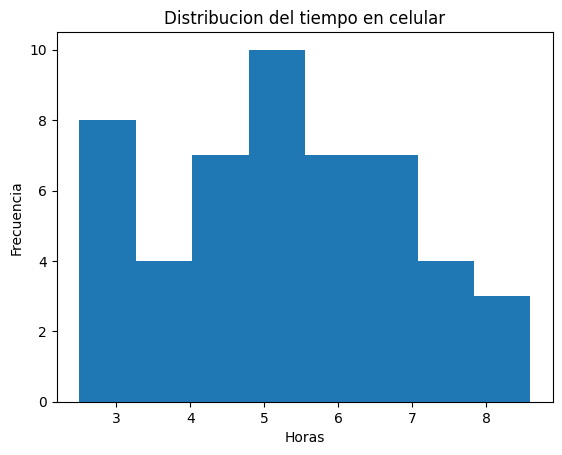

In [30]:
import matplotlib.pyplot as plt

plt.hist(df["tiempo_celular"], bins=8)
plt.title("Distribucion del tiempo en celular")
plt.xlabel("Horas")
plt.ylabel("Frecuencia")
plt.show()

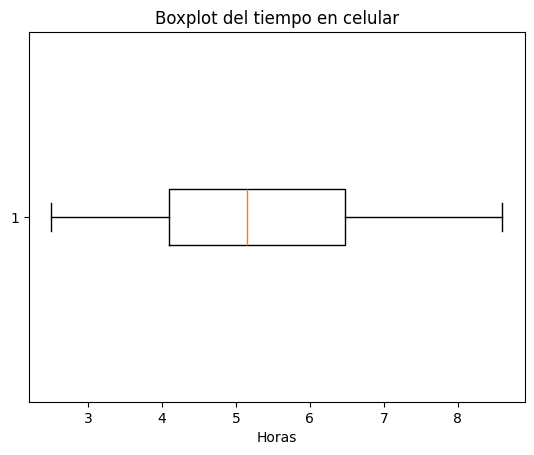

In [33]:
plt.boxplot(df["tiempo_celular"], vert=False)
plt.title("Boxplot del tiempo en celular")
plt.xlabel("Horas")
plt.show()

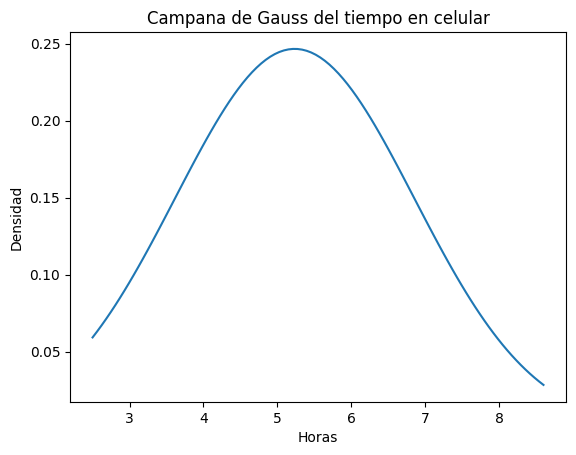

In [36]:
media = df["tiempo_celular"].mean()
desviacion = df["tiempo_celular"].std()

x = np.linspace(
    df["tiempo_celular"].min(),
    df["tiempo_celular"].max(),
    100
)

y = (1 / (desviacion * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - media) / desviacion) ** 2
)

plt.plot(x, y)
plt.title("Campana de Gauss del tiempo en celular")
plt.xlabel("Horas")
plt.ylabel("Densidad")
plt.show()

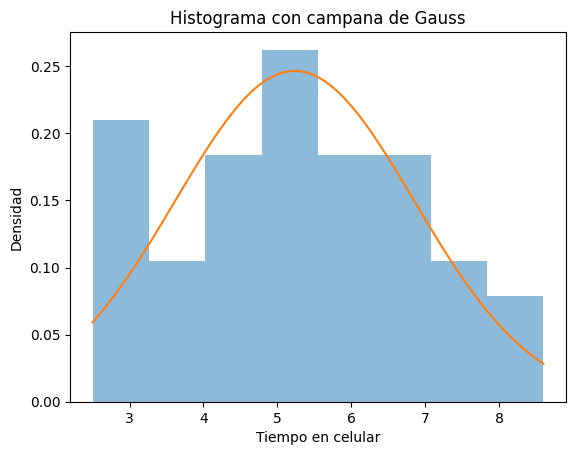

In [37]:
plt.hist(df["tiempo_celular"], bins=8, density=True, alpha=0.5)

media = df["tiempo_celular"].mean()
desviacion = df["tiempo_celular"].std()

x = np.linspace(
    df["tiempo_celular"].min(),
    df["tiempo_celular"].max(),
    100
)

y = ( 1 / (desviacion * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - media) / desviacion) ** 2 
)

plt.plot(x, y)
plt.title("Histograma con campana de Gauss")
plt.xlabel("Tiempo en celular")
plt.ylabel("Densidad")
plt.show()

### Clasificación de datos por rangos

In [38]:
def clasificar_uso(horas):
    if horas < 4:
        return "Bajo"
    elif horas <= 6:
        return "Moderado"
    else:
        return "Alto"

df["categoria_uso"] = df["tiempo_celular"].apply(clasificar_uso)
df.head()

,tiempo_celular,categoria_uso
0,4.5,Moderado
1,2.8,Bajo
2,7.1,Alto
3,5.0,Moderado
4,6.3,Alto


In [39]:
df["categoria_uso"].value_counts()

categoria_uso
Moderado    23
Alto        16
Bajo        11
Name: count, dtype: int64

In [42]:
df["categoria_uso"].value_counts(normalize=True) * 100

categoria_uso
Moderado    46.0
Alto        32.0
Bajo        22.0
Name: proportion, dtype: float64

### Informe automático con interpretación

In [44]:
media = df["tiempo_celular"].mean()
mediana = df["tiempo_celular"].median()
desviacion = df["tiempo_celular"].std()
minimo = df["tiempo_celular"].min()
maximo = df["tiempo_celular"].max()

print(f"Se analizaron {len(df)} registros de tiempo en celular.")
print(f"El promedio de uso fue de {media:.2f} horas.")
print(f"La mediana fue de {mediana:.2f} horas.")
print(f"La desviacion estandar fue de {desviacion:.2f} horas.")
print(f"El valor minimo fue de {minimo:.2f} horas.")
print(f"El valor máximo fue de {maximo:.2f} horas.")

Se analizaron 50 registros de tiempo en celular.
El promedio de uso fue de 5.23 horas.
La mediana fue de 5.15 horas.
La desviacion estandar fue de 1.62 horas.
El valor minimo fue de 2.50 horas.
El valor máximo fue de 8.60 horas.


Ejercicio 1

¿Cuál es el promedio de uso del celular?

In [46]:
print(df["tiempo_celular"].mean())

5.234


Ejercicio 2

¿Cuál es la diferencia entre el máximo y el mínimo?

In [47]:
print(df["tiempo_celular"].max() - df["tiempo_celular"].min())

6.1


Ejercicio 3

¿Cuántas personas usan el celular más de 6 horas?

In [50]:
df[df["tiempo_celular"] > 6].count()

tiempo_celular    16
categoria_uso     16
dtype: int64

In [52]:
print((df["tiempo_celular"] > 6).sum())

16


Ejercicio 4

¿Qué porcentaje usa el celular más de 6 horas?

In [53]:
(df["tiempo_celular"] > 6).mean() * 100

np.float64(32.0)

In [56]:
(df["tiempo_celular"] > 6).mean()

np.float64(0.32)

Ejercicio 5

Clasifica cada dato como bajo, moderado o alto.

In [57]:
df["categoria_uso"] = df["tiempo_celular"].apply(clasificar_uso)
df

,tiempo_celular,categoria_uso
0,4.5,Moderado
1,2.8,Bajo
2,7.1,Alto
3,5.0,Moderado
4,6.3,Alto
5,3.2,Bajo
6,5.8,Moderado
7,4.1,Moderado
8,6.5,Alto
9,3.9,Bajo
